In [2]:
# ссылка на датасет - https://www.kaggle.com/datasets/max-mind/world-cities-database
# это датасет мировых городов, где есть колонки широты и долготы, страны, региона, 
# название города и Accent city (название города с большой буквы)
import pandas as pd
import numpy as np
import category_encoders as ce
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [3]:
df = pd.read_csv('data/worldcitiespop.csv', dtype={'Region': str})

In [76]:
print('Первые 5 строк :\n', df.head())
print('\nПоследние 5 строк : \n', df.tail())
print('\nРазмер : \n', df.shape)
print('\n')
df.info()
# object выдаёт предупреждение - пишем str
print('\n Для текстовых данных: \n', df.describe(include='str'))

Первые 5 строк :
   Country        City  AccentCity Region  Population   Latitude  Longitude
0      ad       aixas       Aixàs     06         NaN  42.483333   1.466667
1      ad  aixirivali  Aixirivali     06         NaN  42.466667   1.500000
2      ad  aixirivall  Aixirivall     06         NaN  42.466667   1.500000
3      ad   aixirvall   Aixirvall     06         NaN  42.466667   1.500000
4      ad    aixovall    Aixovall     06         NaN  42.466667   1.483333

Последние 5 строк : 
         Country         City   AccentCity Region  Population   Latitude  \
3173953      zw   zimre park   Zimre Park     04         NaN -17.866111   
3173954      zw  ziyakamanas  Ziyakamanas     00         NaN -18.216667   
3173955      zw   zizalisari   Zizalisari     04         NaN -17.758889   
3173956      zw      zuzumba      Zuzumba     06         NaN -20.033333   
3173957      zw   zvishavane   Zvishavane     07     79876.0 -20.333333   

         Longitude  
3173953  31.213611  
3173954  27.9500

In [77]:
print('Проверка пустых значений (с 10 строки по 40-ую) : \n', df[10:40].isnull())
print('\nСумма пустых значений по населению (с 1 строки по 100-ую): \n', df.loc[1:100, 'Population'].isnull().sum())
print('\nПроверка дубликатов городов (сумма): \n', df['City'].duplicated().sum())
print('\nПроверка дубликатов городов City - Accent City: \n', df.duplicated(subset=['City', 'AccentCity']).sum())
print('\nПроверка полных дубликатов : \n', df.duplicated().sum())
df_clean = df.drop_duplicates()

Проверка пустых значений (с 10 строки по 40-ую) : 
     Country   City  AccentCity  Region  Population  Latitude  Longitude
10    False  False       False   False        True     False      False
11    False  False       False   False        True     False      False
12    False  False       False   False        True     False      False
13    False  False       False   False        True     False      False
14    False  False       False   False        True     False      False
15    False  False       False   False        True     False      False
16    False  False       False   False        True     False      False
17    False  False       False   False        True     False      False
18    False  False       False   False        True     False      False
19    False  False       False   False        True     False      False
20    False  False       False   False       False     False      False
21    False  False       False   False        True     False      False
22    False 

In [78]:
print('\nТипы данных\n')
print('-' * 30)
print(df_clean.dtypes)
print('\nУдаление пропусков для строк\n')
print('-' * 30)
df_dropped_na = df_clean.dropna()
print('\nРазмер новой DataFrame (нет пустых значений): \n', df_dropped_na.shape)
print('\nРазница в строках между df_clean(без дупликатов) и df_dropped_na(без пустых значений): \n', len(df_clean) - len(df_dropped_na))


Типы данных

------------------------------
Country           str
City              str
AccentCity        str
Region            str
Population    float64
Latitude      float64
Longitude     float64
dtype: object

Удаление пропусков для строк

------------------------------

Размер новой DataFrame (нет пустых значений): 
 (47979, 7)

Разница в строках между df_clean(без дупликатов) и df_dropped_na(без пустых значений): 
 3125668


In [79]:
#Вторая стратегия - заполнение пропусков 
print('\nЗаполнение пропусков средним для строк 1 - 1 000 000\n')
print('-' * 30)
#Заполняем средним значением населения

# работаем только с Population - так как только там есть пропуски
mean_population = df_clean['Population'].mean()
df_filled_na_mean = df_clean[1:1000000].fillna(int(mean_population))
print('\nПервые 5 строк df_filled_na_mean: \n', df_filled_na_mean.head())
#Заполняем медианным значением 
print('-' * 30)
print('\nЗаполнение пропусков медианой для строк 1 000 000 - 2 000 000\n')
print('-' * 30)
median_population = df_clean['Population'].median()
df_filled_na_median = df_clean[1000000:2000000].fillna(median_population)
print('\nПервые 5 строк df_filled_na_median: \n', df_filled_na_median.head())
#Заполняем константой - 50000, т. к.:
#The degree of urbanization is a modern metric to help define what comprises a city: 
#"a population of at least 50,000 inhabitants in contiguous dense grid cells 
#(>1,500 inhabitants per square kilometer)".[19] 
#This metric was "devised over years by the European Commission, OECD, World Bank and others, 
#and endorsed in March [2021] by the United Nations ... 
#largely for the purpose of international statistical comparison"
print('-' * 30)
print('\nЗаполнение пропусков константой = 50 000 для строк 2 000 000 до конца df_clean\n')
print('-' * 30)
const_population = 50000
df_filled_na_const = df_clean[2000000:].fillna(const_population)
print('\nПервые 5 строк df_filled_na_const: \n', df_filled_na_const.head())


Заполнение пропусков средним для строк 1 - 1 000 000

------------------------------

Первые 5 строк df_filled_na_mean: 
   Country        City  AccentCity Region  Population   Latitude  Longitude
1      ad  aixirivali  Aixirivali     06     47719.0  42.466667   1.500000
2      ad  aixirivall  Aixirivall     06     47719.0  42.466667   1.500000
3      ad   aixirvall   Aixirvall     06     47719.0  42.466667   1.500000
4      ad    aixovall    Aixovall     06     47719.0  42.466667   1.483333
5      ad     andorra     Andorra     07     47719.0  42.500000   1.516667
------------------------------

Заполнение пропусков медианой для строк 1 000 000 - 2 000 000

------------------------------

Первые 5 строк df_filled_na_median: 
         Country      City AccentCity Region  Population   Latitude  Longitude
1000283      gb  sandside   Sandside     C9     10779.0  54.216667  -2.800000
1000284      gb     sands      Sands     B9     10779.0  51.633333  -0.783333
1000285      gb     sands   

3125978
  Country                City          AccentCity Region  Population  \
0      ad               aixas               Aixàs     06         NaN   
1      ad          aixirivali          Aixirivali     06         NaN   
2      ad          aixirivall          Aixirivall     06         NaN   
3      ad           aixirvall           Aixirvall     06         NaN   
4      ad            aixovall            Aixovall     06         NaN   
5      ad             andorra             Andorra     07         NaN   
6      ad    andorra la vella    Andorra la Vella     07     20430.0   
7      ad     andorra-vieille     Andorra-Vieille     07         NaN   
8      ad             andorre             Andorre     07         NaN   
9      ad  andorre-la-vieille  Andorre-la-Vieille     07         NaN   

    Latitude  Longitude      Population Category  
0  42.483333   1.466667                      NaN  
1  42.466667   1.500000                      NaN  
2  42.466667   1.500000                      N

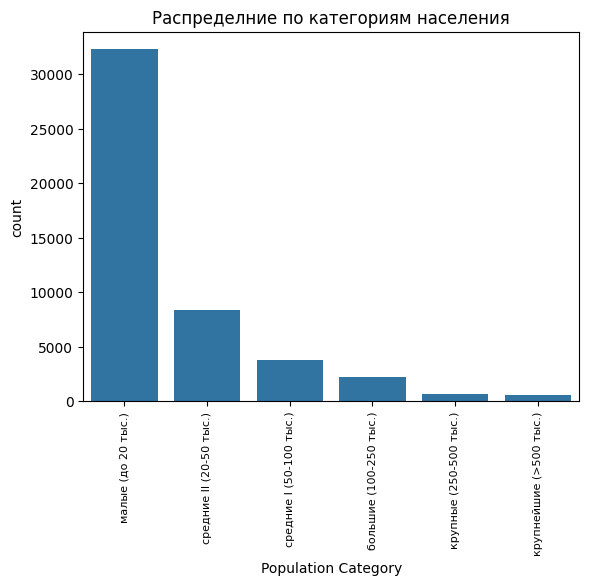


Доля моды среди всех категорий (исключая пропуски) :  67.29262192580242 %

Первые 15 строк df_filled_na_mode: 
    Country                City          AccentCity Region  Population  \
0       ad               aixas               Aixàs     06         NaN   
1       ad          aixirivali          Aixirivali     06         NaN   
2       ad          aixirivall          Aixirivall     06         NaN   
3       ad           aixirvall           Aixirvall     06         NaN   
4       ad            aixovall            Aixovall     06         NaN   
5       ad             andorra             Andorra     07         NaN   
6       ad    andorra la vella    Andorra la Vella     07     20430.0   
7       ad     andorra-vieille     Andorra-Vieille     07         NaN   
8       ad             andorre             Andorre     07         NaN   
9       ad  andorre-la-vieille  Andorre-la-Vieille     07         NaN   
10      ad     andorre-vieille     Andorre-Vieille     07         NaN   
11      ad 

In [82]:
# Расчёт моды и заполнение пропусков 
print(df['Population'].isnull().sum())
bins = [0, 20000, 50000, 100000, 250000, 500000, float('inf')]
labels = [  
    'малые (до 20 тыс.)',
    'средние II (20-50 тыс.)', 
    'средние I (50-100 тыс.)',
    'большие (100-250 тыс.)',  
    'крупные (250-500 тыс.)',   
    'крупнейшие (>500 тыс.)'   
]
df_copy = df_clean.copy()
df_copy['Population Category'] = pd.cut(df_copy['Population'],
                                        bins = bins,
                                        labels = labels)
print(df_copy.head(10))
mode_category = df_copy['Population Category'].mode()[0]
print("\nМода по категориям(население)\n", mode_category)
category_counts = df_copy['Population Category'].value_counts()
print("\nРаспределение категорий\n", category_counts)
mode_count = category_counts.iloc[0]
# также можем построить countplot для населения (мы до этого распределяли население по категориям)
sns.countplot(x = df_copy['Population Category'])
plt.title("Распределние по категориям населения")
plt.xticks(rotation=90, fontsize = 8)
plt.show()
print("\nДоля моды среди всех категорий (исключая пропуски) : ", mode_count / (len(df_copy) - 
                                                           df_copy['Population Category'].isnull().sum()) * 100, '%')
# Тогда заполним пропуски модой в Population Category
df_filled_na_mode = df_copy.copy()
df_filled_na_mode['Population Category'] = df_filled_na_mode['Population Category'].fillna(mode_category)
print('\nПервые 15 строк df_filled_na_mode: \n', df_filled_na_mode.head(15))
category_counts_mode = df_filled_na_mode['Population Category'].value_counts()
print("\nРаспределение категорий в df_filled_na_mode\n", category_counts_mode)


In [80]:
#Числовая статистика
print('\n Для числовых данных: \n', df.describe(), '\n')
print('-' * 30)
#В describe() нет медианы и моды - считаем
print('\nPopulation - мода : ', df['Population'].mode()[0])
print('Latitude (Широта) - мода : ', df['Latitude'].mode()[0])
print('Longitude (Долгота) - мода : ', df['Longitude'].mode()[0], '\n')
print('-' * 30)

print('\nPopulation - медиана : ', df['Population'].median())
print('Latitude - медиана : ', df['Latitude'].median())
print('Longitude - медиана : ', df['Longitude'].median(), '\n')
print('-' * 30)
#В describe() есть 25%, 50%, 75% - посмотрим 5% и 95%
print('\nPopulation - 5-ый перцентиль : ', df['Population'].quantile(0.05))
print('Population - 95-ый перцентиль : ', df['Population'].quantile(0.95))
print('\nLatitude - 5-ый перцентиль : ', df['Latitude'].quantile(0.05))
print('Latitude - 95-ый перцентиль : ', df['Latitude'].quantile(0.95))
print('\nLongitude - 5-ый перцентиль : ', df['Longitude'].quantile(0.05))
print('Longitude - 95-ый перцентиль : ', df['Longitude'].quantile(0.95), '\n')
print('-' * 30)
# Дисперсия выборки
print('\nPopulation - дисперсия : ', np.var(df['Population'], ddof=1))
print('Latitude - дисперсия : ', np.var(df['Latitude'], ddof=1))
print('Longitude - дисперсия : ', np.var(df['Longitude'], ddof=1), '\n')
print('-' * 30)
# Асимметрия (skewness)
print('\nPopulation - skew : ', df['Population'].skew())
# Асимметрия положительная, то есть большинство значений появляются до среднего, mode < median < mean
print('Latitude - skew : ', df['Latitude'].skew())
# Асимметрия отрицательная - значит, большинство значений появляются после среднего, mean < median < mode
print('Longitude - skew : ', df['Longitude'].skew(), '\n')
# Асимметрия отрицательная, большинство значений появляются после среднего, mean < median < mode
print('-' * 30)

#  Эксцесс (kurtosis)
print('\nPopulation - kurt : ', df['Population'].kurt())
#  Значение сильно больше 3 - положительный эксцесс. Значит, много значений разбросано вокруг среднего
print('Latitude - kurt : ', df['Latitude'].kurt())
#  Значение ниже 3 - отрицательный эксцесс. Распределение схоже с нормальным, но более "полое"
print('Longitude - kurt : ', df['Longitude'].kurt(), '\n')
#  Значение ниже 3 - отрицательный эксцесс. Почти такой же эксцесс, как у latitude


 Для числовых данных: 
          Population      Latitude     Longitude
count  4.798000e+04  3.173958e+06  3.173958e+06
mean   4.771957e+04  2.718817e+01  3.708886e+01
std    3.028887e+05  2.195262e+01  6.322302e+01
min    7.000000e+00 -5.493333e+01 -1.799833e+02
25%    3.732000e+03  1.163333e+01  7.303176e+00
50%    1.077900e+04  3.249722e+01  3.528000e+01
75%    2.799050e+04  4.371667e+01  9.570354e+01
max    3.148050e+07  8.248333e+01  1.800000e+02 

------------------------------

Population - мода :  2310.0
Latitude (Широта) - мода :  51.15
Longitude (Долгота) - мода :  23.8 

------------------------------

Population - медиана :  10779.0
Latitude - медиана :  32.4972221
Longitude - медиана :  35.28 

------------------------------

Population - 5-ый перцентиль :  1010.0
Population - 95-ый перцентиль :  142624.39999999962

Latitude - 5-ый перцентиль :  -13.116666699999998
Latitude - 95-ый перцентиль :  56.33157924999999

Longitude - 5-ый перцентиль :  -85.72980554
Longitude - 95

In [10]:
# Энкодинг
# кодируем только country - регион уже представлен числами 
df_encoded = pd.get_dummies(df, columns = ['Country'])
print(df_encoded.tail())
# теперь используем hashing encoder на city
encoder = ce.HashingEncoder(cols = ["City"], n_components = 8)
df_hashed = encoder.fit_transform(df)
print("hashed проверка")
print(df_hashed.tail())

                City   AccentCity Region  Population   Latitude  Longitude  \
3173953   zimre park   Zimre Park     04         NaN -17.866111  31.213611   
3173954  ziyakamanas  Ziyakamanas     00         NaN -18.216667  27.950000   
3173955   zizalisari   Zizalisari     04         NaN -17.758889  31.010556   
3173956      zuzumba      Zuzumba     06         NaN -20.033333  27.933333   
3173957   zvishavane   Zvishavane     07     79876.0 -20.333333  30.033333   

         Country_ad  Country_ae  Country_af  Country_ag  ...  Country_vn  \
3173953       False       False       False       False  ...       False   
3173954       False       False       False       False  ...       False   
3173955       False       False       False       False  ...       False   
3173956       False       False       False       False  ...       False   
3173957       False       False       False       False  ...       False   

         Country_vu  Country_wf  Country_ws  Country_ye  Country_yt  \
317

In [11]:
import sys
!{sys.executable} -m pip install plotly

In [12]:
#Инжиниринг (Feature Engineering)
# определяем самые часто повторяющиеся города
# берем df_dropped_na, потому что в нем меньше значений (чтобы было видно)
top_cities = df_dropped_na["City"].value_counts().nlargest(10000).index
df_dropped_na["City_grouped"] = df_dropped_na["City"].apply(
    lambda x: x if x in top_cities else "Other"
)
print(df_clean.head(50))

   Country                City          AccentCity Region  Population  \
0       ad               aixas               Aixàs     06         NaN   
1       ad          aixirivali          Aixirivali     06         NaN   
2       ad          aixirivall          Aixirivall     06         NaN   
3       ad           aixirvall           Aixirvall     06         NaN   
4       ad            aixovall            Aixovall     06         NaN   
5       ad             andorra             Andorra     07         NaN   
6       ad    andorra la vella    Andorra la Vella     07     20430.0   
7       ad     andorra-vieille     Andorra-Vieille     07         NaN   
8       ad             andorre             Andorre     07         NaN   
9       ad  andorre-la-vieille  Andorre-la-Vieille     07         NaN   
10      ad     andorre-vieille     Andorre-Vieille     07         NaN   
11      ad           ansalonga           Ansalonga     04         NaN   
12      ad               anyos               Anyós 

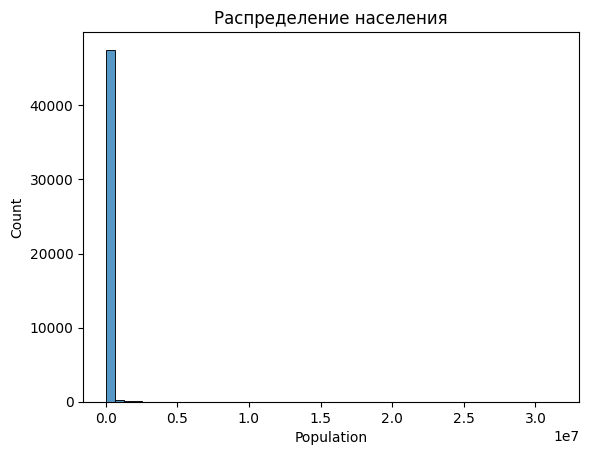

In [31]:
# гистограмма по населению 
sns.histplot(df_dropped_na["Population"], bins = 50, kde = False)
plt.title("Распределение населения")
plt.show()

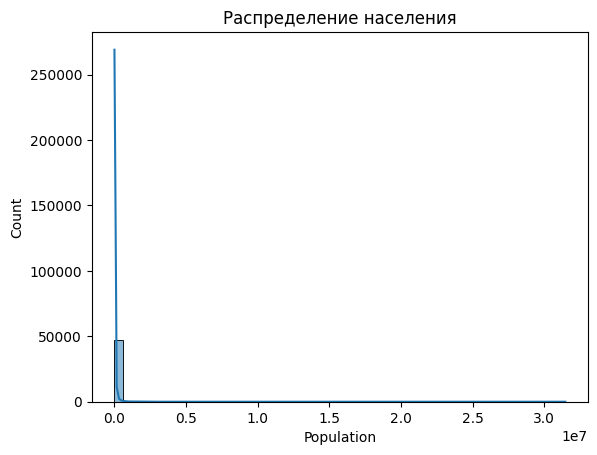

In [26]:
sns.histplot(df_dropped_na["Population"], bins = 50, kde = True)
plt.title("Распределение населения")
plt.show()

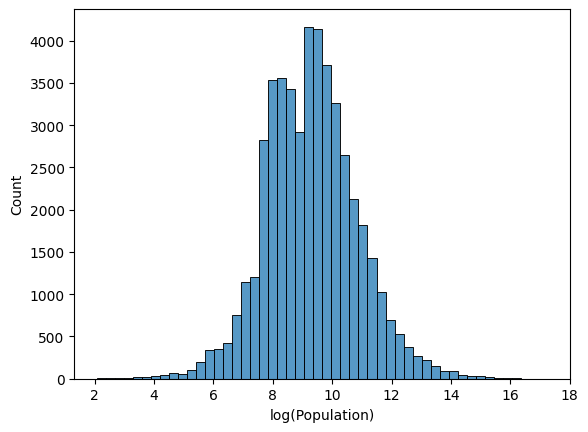

In [30]:
# берем натуральный логарифм для лучшей видимости  
sns.histplot(np.log1p(df_dropped_na["Population"]), bins=50, kde=False)
plt.xlabel("log(Population)")
plt.show()

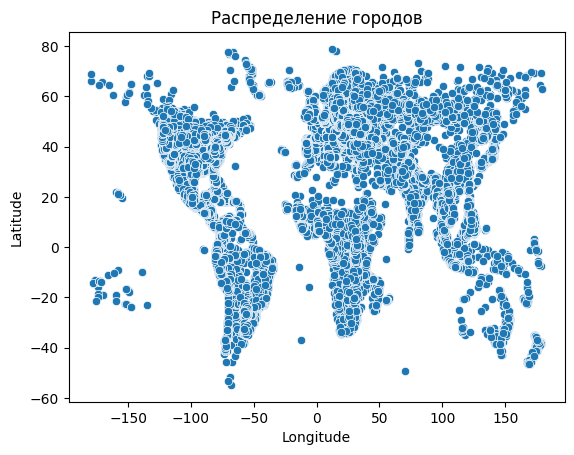

In [34]:
# используем scatter plot для latitude и longitude - условная 
# карта городов
sns.scatterplot(x = "Longitude", y = "Latitude", data = df_dropped_na)
plt.title("Распределение городов")
plt.show()

<Axes: xlabel='Longitude', ylabel='Latitude'>

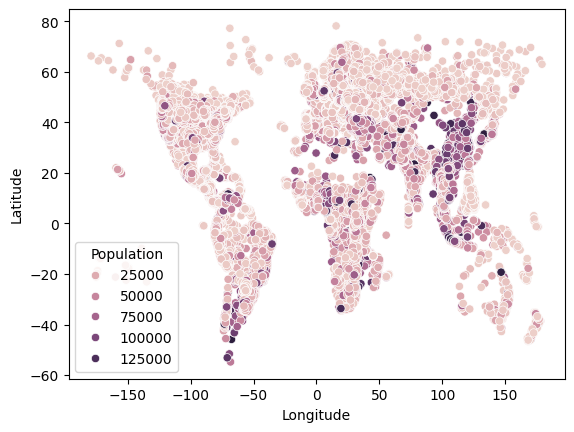

In [45]:
# + связь с начелением. Чем больше точка, тем больше людей 
# визуализации сильно мешают выбросы. Подрежем их по 5%
q_low = df_dropped_na["Population"].quantile(0.05)
q_high = df_dropped_na["Population"].quantile(0.95)

df_dropped_na_filtered = df_dropped_na[
    (df_dropped_na["Population"] >= q_low)&
    (df_dropped_na["Population"] <= q_high)
]

sns.scatterplot(
    x = "Longitude",
    y = "Latitude",
    hue = "Population",
    data = df_dropped_na_filtered
)


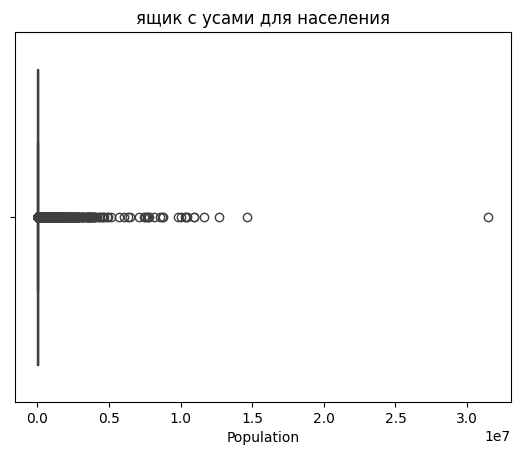

In [40]:
sns.boxplot(x = df_dropped_na["Population"])
plt.title("Ящик с усами для населения")
plt.show()

<Axes: xlabel='Longitude', ylabel='Latitude'>

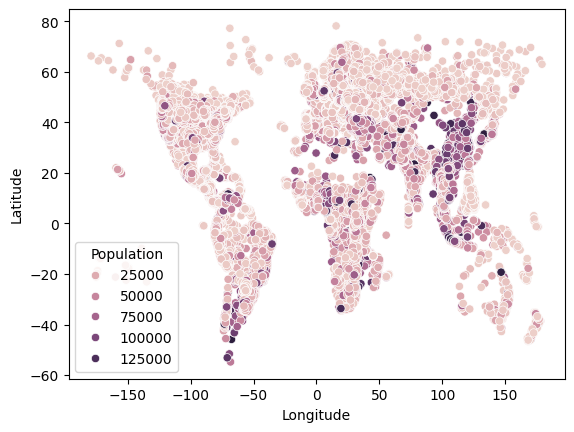

In [46]:
# Теперь подрежем данные исходя из данных в boxplot

df_dropped_na_filtered2 = df_dropped_na[
    (df_dropped_na["Population"] <= 1.5e7)
]

sns.scatterplot(
    x = "Longitude",
    y = "Latitude",
    hue = "Population",
    data = df_dropped_na_filtered
)

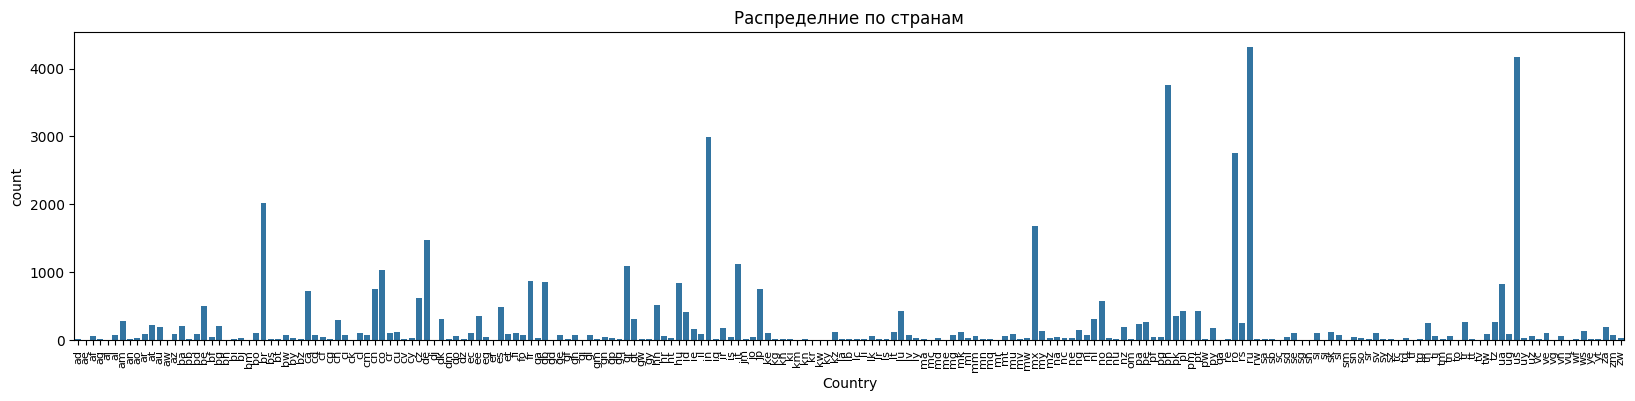

In [60]:
# теперь делаем countplot, используя данные по странам 
plt.figure(figsize=(20, 4))
sns.countplot(x = df_dropped_na["Country"])
plt.title("Распределние по странам")
plt.xticks(rotation=90, fontsize = 8)
plt.show()
# масштаб конечно маленький хех

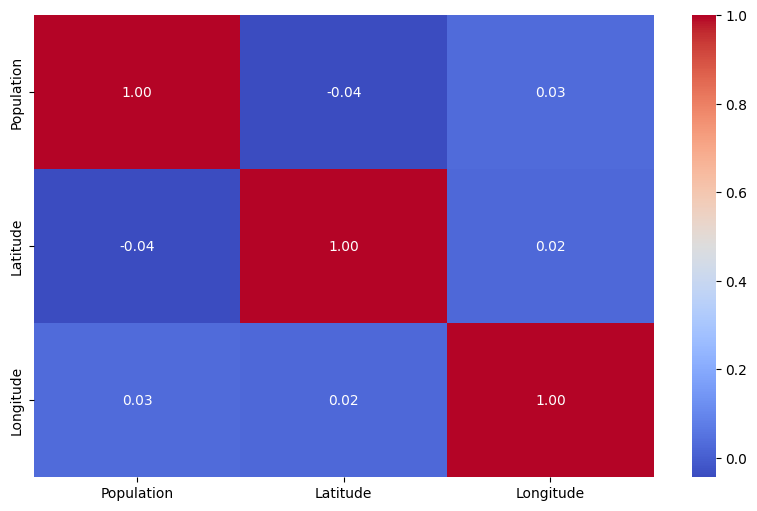

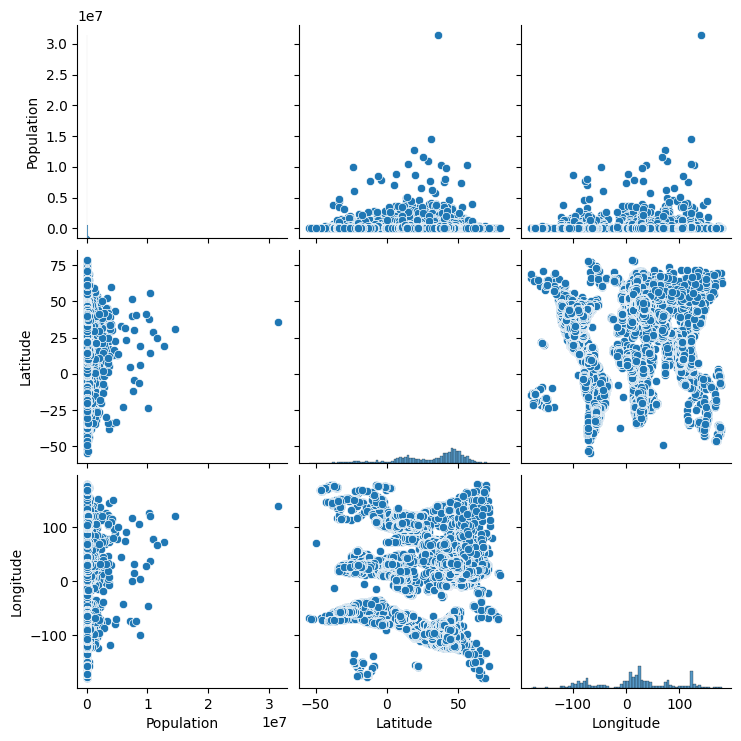

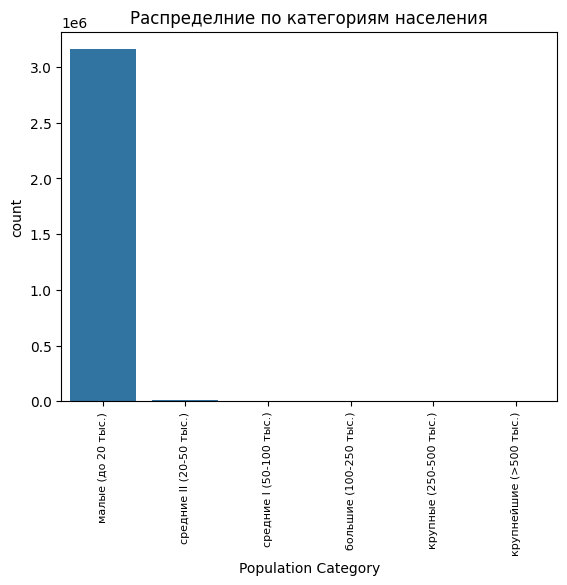

In [81]:
corr = df_dropped_na.corr(numeric_only = True)
plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
# связи особо нет(
sns.pairplot(df_dropped_na)
plt.show()


In [83]:
print("Что можно сказать про датасет? (за базу берем df_dropped_na)")
print("- В датасете df ОЧЕНЬ много пропусков по населению")
print("- В категории населения есть существенный позитивный skew")
print("- Высокая плотность населения на юге Северной Америки, в Центральной Африке и в Азии, на восток в Китае и от него, также в Индонезии")
print("- Рекордсменами по количеству городов в датасете являются Россия, США и Филиппины")
print("- Между числовыми данными корреляция несущественна (модуль коэффициента меньше 0.3)")
print("- В категории населения есть сильные выбросы")
print("- Категориальное разбиение населения показывает, что доминируют малые и средние города, а крупные города встречаются редко")

print("\nГипотезы")
print("1. Количество городов в среднем больше в странах с большей площадью")
print("2. Выбросы по населению в датасете — это мегаполисы с очень большим населением")
print("3. Географические координаты сами по себе не предсказывают население, но могут быть полезны в комбинации")

print("\nПомощь от AI")
print("- Изучение теоретического материала (например, что такое pairplot)")
print("- Проверка, не перепутаны ли данные между таблицами")
print("- Помощь с синтаксисом библиотек")

Что можно сказать про датасет? (за базу берем df_dropped_na)
- В датасете df ОЧЕНЬ много пропусков по населению
- В категории населения есть существенный позитивный skew
- Высокая плотность населения на юге Северной Америки, в Центральной Африке и в Азии, на восток в Китае и от него, также в Индонезии
- Рекордсменами по количеству городов в датасете являются Россия, США и Филиппины
- Между числовыми данными корреляция несущественна (модуль коэффициента меньше 0.3)
- В категории населения есть сильные выбросы
- Категориальное разбиение населения показывает, что доминируют малые и средние города, а крупные города встречаются редко

Гипотезы
1. Количество городов в среднем больше в странах с большей площадью
2. Выбросы по населению в датасете — это мегаполисы с очень большим населением
3. Географические координаты сами по себе не предсказывают население, но могут быть полезны в комбинации

Помощь от AI
- Изучение теоретического материала (например, что такое pairplot)
- Проверка, не переп